Loading data...
✓ 成功加载 NQC 数据: nqc_colbert_e2e.csv
✓ 成功加载 preference 数据: preference.csv

成功合并 43 条查询数据
过滤后剩余 41 条有效数据

数据统计:
             nqc  b_preference_ratio
count  41.000000           41.000000
mean    0.175397            0.502312
std     0.027333            0.197816
min     0.107929            0.000000
25%     0.160130            0.397260
50%     0.169552            0.500000
75%     0.183159            0.568627
max     0.246801            0.961538

相关性分析:
--------------------------------------------------------------------------------
Pearson 相关系数: -0.0867
P-value: 5.8995e-01
✗ 相关性不显著 (p >= 0.05)

Spearman 相关系数: -0.1881
P-value: 2.3889e-01
✗ 相关性不显著 (p >= 0.05)

--------------------------------------------------------------------------------
相关性解释:
→ 负相关：NQC 越高（查询越简单），PRF 受益越少
  这意味着：困难查询更容易从 PRF 中获益

PRF 效果对比:
--------------------------------------------------------------------------------
PRF-Benefit: 9 个查询, 平均 NQC = 0.1760
PRF-Hurt: 11 个查询, 平均 NQC = 0.1781

T-test: t=-0.192, p-

/tmp/ipykernel_3866/1506280171.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='preference', y='nqc', ax=ax2, palette={'PRF-Benefit': 'green', 'PRF-Hurt': 'red'})
/tmp/ipykernel_3866/1506280171.py:148: UserWarning: Glyph 26597 (\N{CJK UNIFIED IDEOGRAPH-67E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3866/1506280171.py:148: UserWarning: Glyph 35810 (\N{CJK UNIFIED IDEOGRAPH-8BE2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3866/1506280171.py:148: UserWarning: Glyph 38590 (\N{CJK UNIFIED IDEOGRAPH-96BE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3866/1506280171.py:148: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3866/1506280171.py:148: UserWarning: Gl

✓ 图表已保存: nqc_prf_correlation.png
✓ 详细数据已保存: nqc_prf_analysis.csv

分析总结:
样本数量: 41 个查询

Pearson 相关系数: -0.0867 (负相关)
Spearman 相关系数: -0.1881
显著性: 不显著 (p >= 0.05)
相关性强度: 弱

结论:
→ NQC 和 PRF 受益程度之间无显著相关性
→ 查询难度可能不是决定 PRF 效果的主要因素

分析完成！


/opt/miniconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26597 (\N{CJK UNIFIED IDEOGRAPH-67E5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35810 (\N{CJK UNIFIED IDEOGRAPH-8BE2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38590 (\N{CJK UNIFIED IDEOGRAPH-96BE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/miniconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65292 (\N{FULLWIDTH COMMA}) missing from font(s) DejaVu Sans

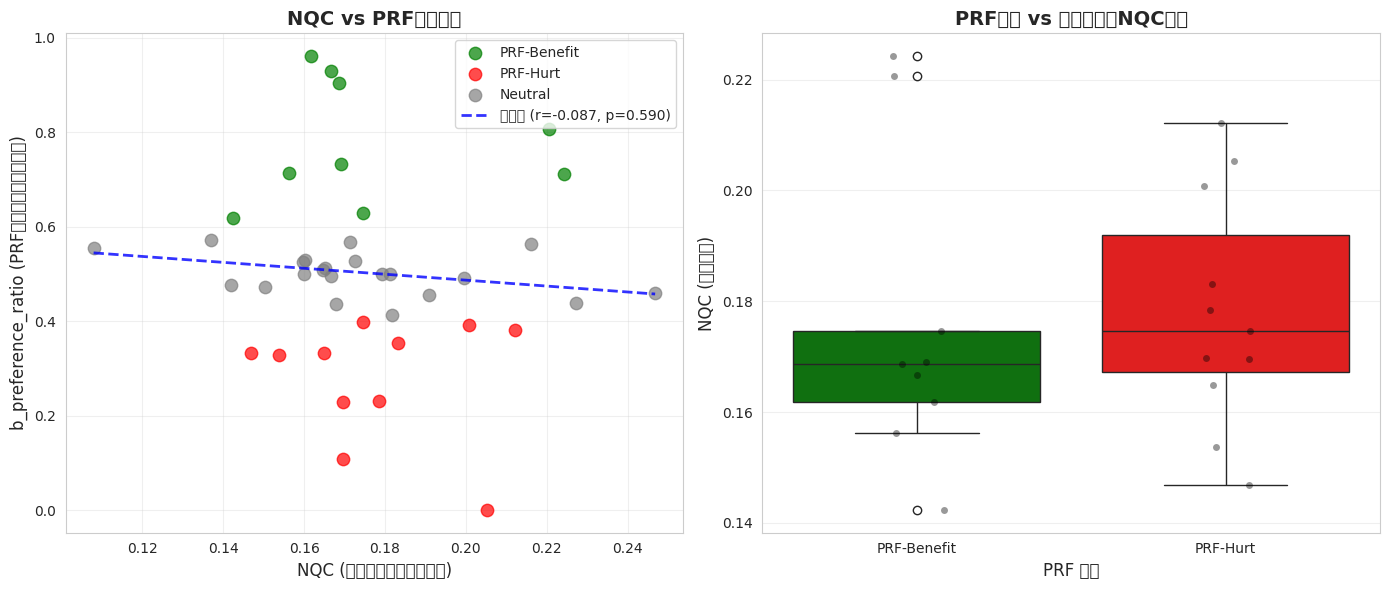

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 设置绘图风格
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# 读取数据
print("=" * 80)
print("Loading data...")

# 尝试多个可能的路径
nqc_paths = ['nqc_colbert_e2e.csv', '/mnt/user-data/uploads/nqc_colbert_e2e.csv', 
             '/home/claude/nqc_colbert_e2e.csv']
preference_paths = ['preference.csv', '/mnt/user-data/uploads/preference.csv',
                   '/home/claude/preference.csv']

nqc_df = None
for path in nqc_paths:
    try:
        nqc_df = pd.read_csv(path)
        print(f"✓ 成功加载 NQC 数据: {path}")
        break
    except FileNotFoundError:
        continue

if nqc_df is None:
    print("错误: 找不到 nqc_colbert_e2e.csv 文件")
    print("请先运行 NQC 计算代码生成该文件，或上传该文件")
    exit(1)

preference_df = None
for path in preference_paths:
    try:
        preference_df = pd.read_csv(path)
        print(f"✓ 成功加载 preference 数据: {path}")
        break
    except FileNotFoundError:
        continue

if preference_df is None:
    print("错误: 找不到 preference.csv 文件")
    exit(1)

# 合并数据
merged_df = pd.merge(nqc_df, preference_df, on='qid', how='inner')
print(f"\n成功合并 {len(merged_df)} 条查询数据")

# 过滤掉缺失值
merged_df = merged_df.dropna(subset=['nqc', 'b_preference_ratio'])
print(f"过滤后剩余 {len(merged_df)} 条有效数据")

print("\n" + "=" * 80)
print("数据统计:")
print(merged_df[['nqc', 'b_preference_ratio']].describe())

# ========== 1. 相关性分析 ==========
print("\n" + "=" * 80)
print("相关性分析:")
print("-" * 80)

# Pearson 相关系数（线性相关）
pearson_corr, pearson_pval = stats.pearsonr(merged_df['nqc'], merged_df['b_preference_ratio'])
print(f"Pearson 相关系数: {pearson_corr:.4f}")
print(f"P-value: {pearson_pval:.4e}")
if pearson_pval < 0.05:
    print("✓ 相关性显著 (p < 0.05)")
else:
    print("✗ 相关性不显著 (p >= 0.05)")

# Spearman 相关系数（秩相关，对非线性关系更敏感）
spearman_corr, spearman_pval = stats.spearmanr(merged_df['nqc'], merged_df['b_preference_ratio'])
print(f"\nSpearman 相关系数: {spearman_corr:.4f}")
print(f"P-value: {spearman_pval:.4e}")
if spearman_pval < 0.05:
    print("✓ 相关性显著 (p < 0.05)")
else:
    print("✗ 相关性不显著 (p >= 0.05)")

# 相关性解释
print("\n" + "-" * 80)
print("相关性解释:")
if pearson_corr > 0:
    print("→ 正相关：NQC 越高（查询越简单），PRF 受益越多")
    print("  这意味着：简单查询更容易从 PRF 中获益")
else:
    print("→ 负相关：NQC 越高（查询越简单），PRF 受益越少")
    print("  这意味着：困难查询更容易从 PRF 中获益")

# ========== 2. 简单对比分析 ==========
print("\n" + "=" * 80)
print("PRF 效果对比:")
print("-" * 80)

prf_benefit = merged_df[merged_df['preference'] == 'PRF-Benefit']
prf_hurt = merged_df[merged_df['preference'] == 'PRF-Hurt']

print(f"PRF-Benefit: {len(prf_benefit)} 个查询, 平均 NQC = {prf_benefit['nqc'].mean():.4f}")
print(f"PRF-Hurt: {len(prf_hurt)} 个查询, 平均 NQC = {prf_hurt['nqc'].mean():.4f}")

if len(prf_benefit) > 0 and len(prf_hurt) > 0:
    t_stat, t_pval = stats.ttest_ind(prf_benefit['nqc'], prf_hurt['nqc'])
    print(f"\nT-test: t={t_stat:.3f}, p-value={t_pval:.4f}")
    if t_pval < 0.05:
        print("✓ PRF-Benefit 和 PRF-Hurt 的 NQC 有显著差异")
    else:
        print("✗ 两组 NQC 无显著差异")

# ========== 3. 可视化 ==========
print("\n" + "=" * 80)
print("生成可视化图表...")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 图1: 散点图 + 回归线
ax1 = axes[0]
colors = {'PRF-Benefit': 'green', 'Neutral': 'gray', 'PRF-Hurt': 'red', 'Insufficient-Data': 'lightgray'}
for pref_type in merged_df['preference'].unique():
    subset = merged_df[merged_df['preference'] == pref_type]
    ax1.scatter(subset['nqc'], subset['b_preference_ratio'], 
               label=pref_type, alpha=0.7, s=80, color=colors.get(pref_type, 'blue'))

# 添加回归线
z = np.polyfit(merged_df['nqc'], merged_df['b_preference_ratio'], 1)
p = np.poly1d(z)
x_line = np.linspace(merged_df['nqc'].min(), merged_df['nqc'].max(), 100)
ax1.plot(x_line, p(x_line), "b--", alpha=0.8, linewidth=2, 
         label=f'回归线 (r={pearson_corr:.3f}, p={pearson_pval:.3f})')
ax1.set_xlabel('NQC (查询难度，越高越简单)', fontsize=12)
ax1.set_ylabel('b_preference_ratio (PRF受益程度，越高越好)', fontsize=12)
ax1.set_title('NQC vs PRF受益程度', fontsize=14, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# 图2: 箱线图
ax2 = axes[1]
plot_data = merged_df[merged_df['preference'].isin(['PRF-Benefit', 'PRF-Hurt'])]
sns.boxplot(data=plot_data, x='preference', y='nqc', ax=ax2, palette={'PRF-Benefit': 'green', 'PRF-Hurt': 'red'})
sns.stripplot(data=plot_data, x='preference', y='nqc', color='black', alpha=0.4, size=5, ax=ax2)
ax2.set_xlabel('PRF 效果', fontsize=12)
ax2.set_ylabel('NQC (查询难度)', fontsize=12)
ax2.set_title('PRF受益 vs 受损查询的NQC分布', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('nqc_prf_correlation.png', dpi=300, bbox_inches='tight')
print("✓ 图表已保存: nqc_prf_correlation.png")

# ========== 4. 保存结果 ==========
output_df = merged_df[['qid', 'nqc', 'b_preference_ratio', 'preference']].sort_values('nqc')
output_df.to_csv('nqc_prf_analysis.csv', index=False)
print("✓ 详细数据已保存: nqc_prf_analysis.csv")

# ========== 5. 总结 ==========
print("\n" + "=" * 80)
print("分析总结:")
print("=" * 80)
print(f"样本数量: {len(merged_df)} 个查询")
print(f"\nPearson 相关系数: {pearson_corr:.4f} ({'正相关' if pearson_corr > 0 else '负相关'})")
print(f"Spearman 相关系数: {spearman_corr:.4f}")
print(f"显著性: {'显著 (p < 0.05)' if pearson_pval < 0.05 else '不显著 (p >= 0.05)'}")

if abs(pearson_corr) < 0.3:
    strength = "弱"
elif abs(pearson_corr) < 0.7:
    strength = "中等"
else:
    strength = "强"
print(f"相关性强度: {strength}")

print("\n结论:")
if pearson_corr > 0 and pearson_pval < 0.05:
    print("→ NQC 和 PRF 受益程度呈显著正相关")
    print("→ 简单查询（高 NQC）更容易从 PRF 中获益")
elif pearson_corr < 0 and pearson_pval < 0.05:
    print("→ NQC 和 PRF 受益程度呈显著负相关")
    print("→ 困难查询（低 NQC）更容易从 PRF 中获益")
else:
    print("→ NQC 和 PRF 受益程度之间无显著相关性")
    print("→ 查询难度可能不是决定 PRF 效果的主要因素")

print("\n" + "=" * 80)
print("分析完成！")